# Task
Phân loại tập dữ liệu nhận dạng chữ cái "Letter Recognition" từ UCI Machine Learning Repository bằng thuật toán Naïve Bayes, bao gồm tải dữ liệu, chuẩn bị, huấn luyện, đánh giá hiệu suất (độ chính xác, báo cáo phân loại) và trực quan hóa kết quả (ma trận nhầm lẫn).

## Tải dữ liệu

### Subtask:
Tải tập dữ liệu "Letter Recognition" từ UCI Machine Learning Repository vào một DataFrame của pandas.


**Reasoning**:
The subtask requires downloading the 'Letter Recognition' dataset from a given URL and loading it into a pandas DataFrame. I will use pandas to read the CSV directly from the provided URL, specifying the column names based on the dataset's description to ensure proper data interpretation.



**Reasoning**:
The previous attempt to download the dataset failed due to an SSL certificate verification error (URLError: [SSL: CERTIFICATE_VERIFY_FAILED]). To bypass this issue and successfully load the data, I will use the `requests` library to fetch the content with SSL verification disabled (`verify=False`) and then read the downloaded text into a pandas DataFrame using `io.StringIO`.



In [2]:
import pandas as pd
import requests
import io

# URL for the Letter Recognition dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data'

# Column names based on the dataset description:
# The first column is the target variable (letter), and the subsequent 16 columns are features.
column_names = [
    'letter', 'xbox', 'ybox', 'width', 'height', 'onpix', 'xbar', 'ybar',
    'x2bar', 'y2bar', 'xycov', 'xegv', 'yegv', 'corr', 'vbar', 'nbar', 'dbar'
]

# Download the content with SSL verification disabled due to certificate issues
try:
    response = requests.get(url, verify=False)
    response.raise_for_status()  # Raise an exception for HTTP errors
    data_content = response.text
except requests.exceptions.RequestException as e:
    print(f"Error downloading data: {e}")
    raise  # Re-raise the exception after printing

# Read the dataset into a pandas DataFrame from the downloaded text content
df_letter_recognition = pd.read_csv(io.StringIO(data_content), header=None, names=column_names)

# Display the first few rows of the DataFrame to verify the load
print("First 5 rows of the dataset:")
print(df_letter_recognition.head())

# Display basic information about the DataFrame
print("\nDataFrame Info:")
df_letter_recognition.info()

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'archive.ics.uci.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


First 5 rows of the dataset:
  letter  xbox  ybox  width  height  onpix  xbar  ybar  x2bar  y2bar  xycov  \
0      T     2     8      3       5      1     8    13      0      6      6   
1      I     5    12      3       7      2    10     5      5      4     13   
2      D     4    11      6       8      6    10     6      2      6     10   
3      N     7    11      6       6      3     5     9      4      6      4   
4      G     2     1      3       1      1     8     6      6      6      6   

   xegv  yegv  corr  vbar  nbar  dbar  
0    10     8     0     8     0     8  
1     3     9     2     8     4    10  
2     3     7     3     7     3     9  
3     4    10     6    10     2     8  
4     5     9     1     7     5    10  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non

**Reasoning**:
The previous step successfully loaded the dataset. Now, I need to prepare the data for machine learning by separating features from the target variable and encoding the categorical target variable into numerical form, as Naïve Bayes algorithms typically require numerical input for the target.



In [3]:
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = df_letter_recognition.drop('letter', axis=1)
y = df_letter_recognition['letter']

# Encode the target variable 'letter' into numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Display the first 5 encoded labels and the classes found by the encoder
print("First 5 encoded labels:")
print(y_encoded[:5])
print("\nClasses found by LabelEncoder:")
print(label_encoder.classes_)

print("\nShape of features (X):", X.shape)
print("Shape of encoded target (y_encoded):", y_encoded.shape)

First 5 encoded labels:
[19  8  3 13  6]

Classes found by LabelEncoder:
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']

Shape of features (X): (20000, 16)
Shape of encoded target (y_encoded): (20000,)


## Chuẩn bị dữ liệu

### Subtask:
Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra.


**Reasoning**:
I need to split the data into training and testing sets using `train_test_split` from `sklearn.model_selection`, as per the instructions. I will use the `X` (features) and `y_encoded` (target) variables that were prepared in the previous step. I will also set `test_size` to 0.3 and `random_state` to 42 for reproducibility, then print the shapes of the resulting sets.



In [4]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Print the shapes of the resulting sets to verify the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (14000, 16)
Shape of X_test: (6000, 16)
Shape of y_train: (14000,)
Shape of y_test: (6000,)


## Huấn luyện mô hình Naïve Bayes

### Subtask:
Áp dụng và huấn luyện một thuật toán Naïve Bayes (ví dụ: Gaussian Naïve Bayes) trên tập dữ liệu huấn luyện.


**Reasoning**:
I need to import the Gaussian Naïve Bayes classifier, instantiate it, and then train the model using the provided training data (X_train and y_train).



In [5]:
from sklearn.naive_bayes import GaussianNB

# Instantiate the Gaussian Naïve Bayes model
gnb = GaussianNB()

# Train the model using the training data
gnb.fit(X_train, y_train)

print("Gaussian Naïve Bayes model trained successfully.")

Gaussian Naïve Bayes model trained successfully.


## Đánh giá mô hình

### Subtask:
Đánh giá hiệu suất của mô hình bằng cách tính độ chính xác và tạo báo cáo phân loại trên tập dữ liệu kiểm tra.


**Reasoning**:
I need to make predictions using the trained Naïve Bayes model on the test data and then calculate its accuracy and generate a classification report to evaluate its performance.



In [6]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred = gnb.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Generate a classification report
# For the classification report, we need to map the encoded labels back to original letter names
# to make the report more readable. The label_encoder.classes_ attribute holds this mapping.
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Model Accuracy: 0.6432

Classification Report:
              precision    recall  f1-score   support

           A       0.85      0.92      0.88       232
           B       0.52      0.68      0.59       229
           C       0.71      0.72      0.71       201
           D       0.62      0.77      0.69       250
           E       0.62      0.35      0.45       238
           F       0.67      0.72      0.69       211
           G       0.51      0.55      0.53       230
           H       0.52      0.31      0.39       218
           I       0.51      0.74      0.61       221
           J       0.82      0.71      0.76       228
           K       0.43      0.47      0.45       188
           L       0.97      0.76      0.85       231
           M       0.68      0.90      0.77       252
           N       0.88      0.67      0.76       231
           O       0.52      0.71      0.60       218
           P       0.88      0.73      0.80       248
           Q       0.64      0.53 

## Trực quan hóa kết quả

### Subtask:
Trực quan hóa ma trận nhầm lẫn hoặc kết quả dự đoán của mô hình.


**Reasoning**:
I need to visualize the confusion matrix by importing necessary libraries, calculating the confusion matrix, and then plotting it as a heatmap with appropriate labels and title for better readability.



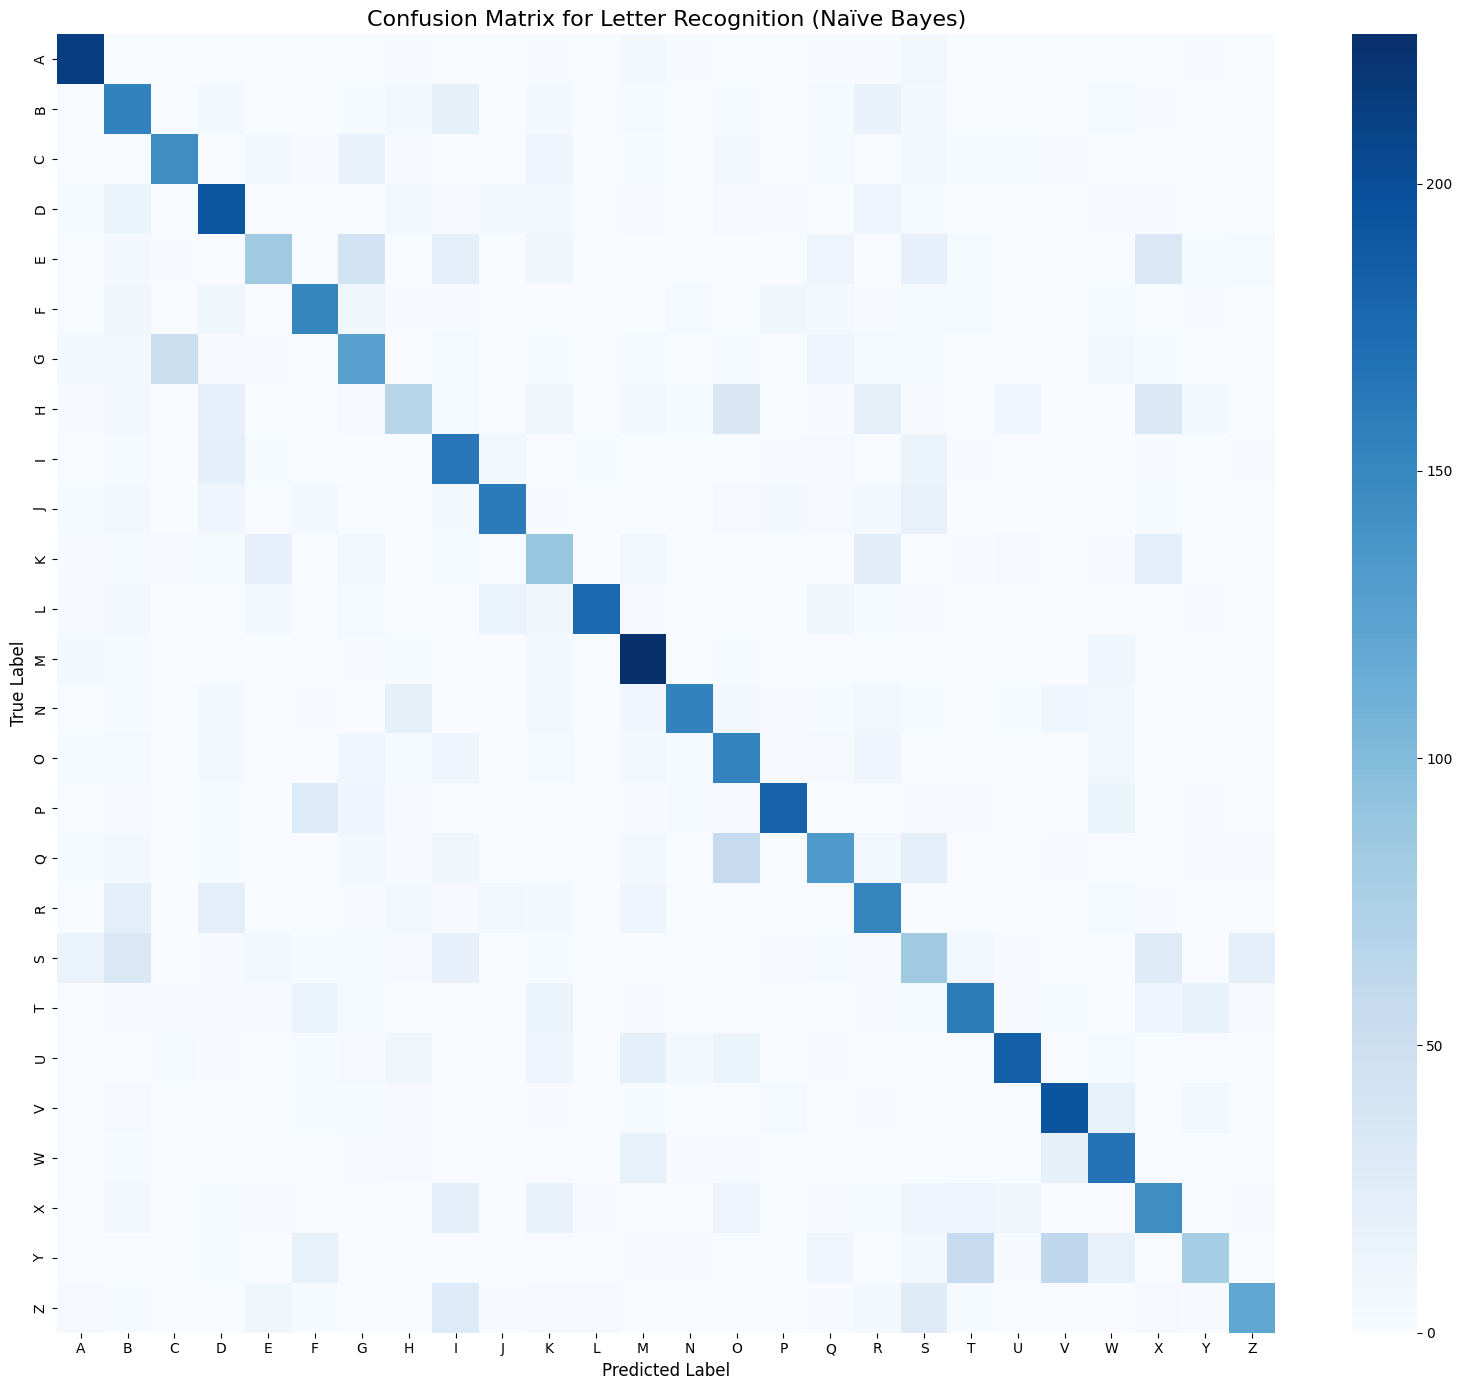

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Set up the matplotlib figure and axes for better readability
plt.figure(figsize=(16, 14))

# Create a heatmap of the confusion matrix
sns.heatmap(
    cm,
    annot=False,  # Set to False to avoid overcrowding for many classes
    fmt='d',      # Format as integers
    cmap='Blues', # Color map
    xticklabels=label_encoder.classes_, # Label x-axis with actual letter names
    yticklabels=label_encoder.classes_  # Label y-axis with actual letter names
)

# Add title and labels
plt.title('Confusion Matrix for Letter Recognition (Naïve Bayes)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


## Nhiệm vụ cuối cùng

### Subtask:
Tóm tắt kết quả phân loại, bao gồm độ chính xác và các phân tích khác về hiệu suất của mô hình.


## Summary:

### Data Analysis Key Findings

*   **Data Loading and Preparation**: The "Letter Recognition" dataset, comprising 20,000 entries and 17 columns (16 features and 1 target), was successfully loaded and prepared. The categorical 'letter' target variable was encoded into numerical labels. The dataset was then split into training (14,000 samples) and testing (6,000 samples) sets, with 30% of the data allocated for testing.
*   **Model Training**: A Gaussian Naïve Bayes model was successfully instantiated and trained on the prepared training data.
*   **Model Performance (Accuracy)**: The trained Gaussian Naïve Bayes model achieved an accuracy of **0.6432** on the test set.
*   **Model Performance (Classification Report)**: The model exhibited varied performance across different letters. For instance, it performed well on 'A' with a precision of 0.85, recall of 0.92, and F1-score of 0.88. However, it performed poorly on 'S' with a precision, recall, and F1-score of 0.36. The macro average for precision, recall, and F1-score was approximately 0.66, 0.64, and 0.64, respectively.
*   **Visualization**: A confusion matrix heatmap was successfully generated, providing a visual representation of the model's predictions versus the true labels for all 26 letter classes.

### Insights or Next Steps

*   The current accuracy of 64.32% suggests that while the Gaussian Naïve Bayes model provides a baseline, there is significant room for improvement in letter recognition performance. This model struggles with distinguishing certain letters, as indicated by the varied F1-scores in the classification report.
*   Further steps should involve exploring more sophisticated classification algorithms (e.g., Support Vector Machines, Random Forests, Neural Networks) or applying feature engineering techniques to potentially improve the model's ability to discriminate between letters.
